# Phase 5 — J2塑性と材料点更新：答案Notebook

[本文](../docs/texts/phase5-j2-plasticity.md) / [学習ログ](../docs/learning-log.md)

## 進め方

6演習・100点。記述・数式・コード・保存出力をこのNotebookへまとめて提出する。
各問で予測を書いてから実装し、予測と異なった結果を説明する。
実装するのは微小ひずみ・3D・等方弾性・関連J2塑性・線形等方硬化の材料点モデル。
完成したソルバコードは配布しない。関数の分け方・内部実装・追加検証は自分で設計する。

コードセルの関数は `NotImplementedError` の答案欄であり、未実装時はチェックを「未実装」と表示する。
これは合格ではない。提出時はカーネルを再起動して全セル実行し、「未実装」を残さない。
自作の表・グラフ用セルは各問の直後へ自由に追加してよい。

| 問 | 内容 | 点数（記述／実装・検証） |
| --- | --- | --- |
| 1 | 応力不変量と弾性分解 | 15（7／8） |
| 2 | 流れ則・累積量・硬化係数 | 20（12／8） |
| 3 | 3D radial return | 25（8／17） |
| 4 | 反転負荷と履歴 | 15（5／10） |
| 5 | 回転・増分細分化・入力不変 | 15（5／10） |
| 6 | FEM・CAE結果レビュー | 10（10／0） |

必須依存はNumPy、描画にはMatplotlibを使う。応力・弾性係数はMPa、ひずみは無次元。
全テンソルは対称3×3配列。せん断ひずみはテンソル成分を入れる。
配布チェックは最低限の目印で、指定された自作検証の代わりにはならない。

In [7]:
import numpy as np
import matplotlib.pyplot as plt

E, nu, sigma_y0, H = 210000.0, 0.3, 250.0, 1000.0
G = E / (2 * (1 + nu))
K = E / (3 * (1 - 2 * nu))
I = np.eye(3)
Z = np.zeros((3, 3))

def checkpoint(label, check):
    try:
        check()
    except NotImplementedError:
        print(f"未実装: {label}（検証未完了）")
    else:
        print(f"PASS: {label}（自作検証・記述も必要）")

print(f"G={G:.6f} MPa, K={K:.6f} MPa")

G=80769.230769 MPa, K=175000.000000 MPa


## 演習1 — 体積・偏差と降伏判定（15点）

本文1〜2節。$p$ は引張正の平均応力、$q$ はMises応力、$J_2=\mathbf s:\mathbf s/2$。

1. 一軸応力、純せん断、静水圧応力の $\mathbf s,J_2,q$ を導出し、純せん断の縮約で係数2が生じる理由を書く（7点）。
2. `invariants(sigma)` を実装する。返り値は `(p, s, J2, q)`。`s` は3×3配列、他はスカラー。`elastic_stress(eps, E, nu)` も実装する。入力を変更しない（5点）。
3. 配布チェックに加え、任意の対称応力への静水圧応力追加で $q$ が不変なことを自作テストする。比較したテンソルと差を表示する（3点）。

対称3×3・有限値を必須とし、異常形状・非対称・NaNを `ValueError` で拒否する。
弾性係数は有限スカラーで $E>0,-1<\nu<1/2$。対称性の許容誤差は自分で明記する。

### 記述・数式の答案

- 導出・予測：
  - 一軸応力：$\mathrm{diag}(\sigma,0,0)$
    - $\mathbf{s}=\mathrm{diag}(\frac{2}{3}\sigma, -\frac{1}{3}\sigma, -\frac{1}{3}\sigma)$
    - $J_2=\frac{1}{3}\sigma^2$
    - $q=|\sigma|$
  - 純せん断：$\begin{bmatrix}0&&\tau&&0\\\tau&&0&&0\\0&&0&&0\\\end{bmatrix}$
    - $\mathbf{s}=\begin{bmatrix}0&&\tau&&0\\\tau&&0&&0\\0&&0&&0\\\end{bmatrix}$
    - $J_2=\tau^2$
    - $q=\sqrt{3}|\tau|$
    - 純せん断では$\boldsymbol{s}:\boldsymbol{s}=s_{xy}^2+s_{yx}^2=2\tau^2$
  - 静水圧応力：$p\mathbf{I}$
    - $\mathbf{s}=\mathbf{0}$
    - $J_2=0$
    - $q=0$
- 計算結果と検証の解釈：

静水圧応力を加えても偏差応力は変化しないため、$q$は不変である

In [8]:
def invariants(sigma):
    """応力テンソルの平均応力、偏差応力、J2、Mises応力を返す。

    Parameters
    ----------
    sigma : array-like, shape (3, 3)
        対称なCauchy応力テンソル。単位はMPa。

    Returns
    -------
    tuple
        (p, s, J2, q)。pは平均応力、sは偏差応力、
        J2は第二偏差応力不変量、qはMises応力。
    """
    # TODO: 入力検証、平均・偏差・二重縮約
    if sigma.shape != (3,3) or not np.all(np.isfinite(sigma)):
        raise ValueError("応力テンソルは(3,3)の配列であり、有限値かつ数値でなければならない")
    if not np.allclose(sigma, sigma.T, atol=1e-9):
        raise ValueError("応力テンソルは対称でなければならない")
    p = np.trace(sigma)/3.
    s = sigma-p*I
    j2 = (s*s).sum()/2.
    q = np.sqrt(3.*j2)
    return p, s, j2, q
def elastic_stress(eps, E, nu):
    """等方線形弾性体の応力テンソルを計算する。

    Parameters
    ----------
    eps : array-like, shape (3, 3)
        対称な微小ひずみテンソル。無次元。
    E : float
        ヤング率。単位はMPa。
    nu : float
        ポアソン比。-1 < nu < 0.5。

    Returns
    -------
    numpy.ndarray
        Cauchy応力テンソル。単位はMPa。
    """
    # TODO: 体積成分と偏差成分への弾性応答
    if eps.shape != (3,3) or not np.all(np.isfinite(eps)):
        raise ValueError("ひずみテンソルは(3,3)の配列であり、有限値かつ数値でなければならない")
    if not np.allclose(eps, eps.T, atol=1e-9):
        raise ValueError("ひずみテンソルは対称でなければならない")
    if not np.isscalar(E) or not np.isfinite(E) or E <= 0.:
        raise ValueError("弾性係数Eは正の有限スカラーでなければならない")
    if not np.isscalar(nu) or not np.isfinite(nu) or nu <= -1. or nu >= 0.5:
        raise ValueError("弾性係数nuは -1 < nu < 0.5 の有限スカラーでなければならない")
    G = E/(2*(1+nu))
    K = E/(3*(1-2*nu))
    return K*np.trace(eps)*I+2.*G*(eps-np.trace(eps)/3.*I)

def check_ex1():
    cases = [(np.diag([300., 0., 0.]), 300.),
             (np.array([[0., 100., 0.], [100., 0., 0.], [0., 0., 0.]]), np.sqrt(3)*100),
             (100.*I, 0.)]
    for stress, q_expected in cases:
        p, s, j2, q = invariants(stress)
        np.testing.assert_allclose(q, q_expected, atol=1e-9, rtol=1e-10)
        np.testing.assert_allclose(stress, p*I+s, atol=1e-9)
        np.testing.assert_allclose(np.trace(s), 0., atol=1e-9)
    np.testing.assert_allclose(elastic_stress(1e-4*I, E, nu), 52.5*I, atol=1e-9)

checkpoint("演習1の基準値", check_ex1)
# TODO: 自作検証と表示を追加
stress_test = np.array([[50., 100., 200.], [100., 150., 300.], [200., 300., 250.]])
stress_add_p = stress_test+400.*I
p_test, s_test, j2_test, q_test = invariants(stress_test)
p_add_p, s_add_p, j2_add_p, q_add_p = invariants(stress_add_p)
assert np.allclose(s_test, s_add_p, atol=1e-9)
print("対称応力              [MPa]", stress_test)
print("静水圧応力追加後の応力 [MPa]", stress_add_p)
print("Mises応力の差         [MPa]", q_add_p-q_test)

PASS: 演習1の基準値（自作検証・記述も必要）
対称応力              [MPa] [[ 50. 100. 200.]
 [100. 150. 300.]
 [200. 300. 250.]]
静水圧応力追加後の応力 [MPa] [[450. 100. 200.]
 [100. 550. 300.]
 [200. 300. 650.]]
Mises応力の差         [MPa] 0.0


## 演習2 — 流れ則・相当塑性ひずみ・硬化（20点）

本文3〜4節。

1. $q^2=3\mathbf s:\mathbf s/2$ を微分して $\partial f/\partial\boldsymbol\sigma=3\mathbf s/(2q)$ を導く。トレースゼロと $\dot\alpha=\dot\lambda$ を示す。相補条件を使い、降伏面上の弾性除荷を説明する（8点）。
2. 一軸応力の単調引張について $E_t=EH/(E+H)$ を導出する。$E_t=1000$ MPaの測定曲線から $H$ を計算し、共通定数の $H=1000$ MPaとの違いを説明する（4点）。
3. `accumulate_alpha(dep_history)` を実装する。入力は各ステップの塑性ひずみ増分 `(m,3,3)`、出力は初期値0を含む `(m+1,)` の累積量。各増分内の流れ方向を一定とみなし、増分ノルムを加算する。空履歴 `(0,3,3)` は `[0.]` を返す（5点）。
4. $\mathbf A=\operatorname{diag}(1,-1/2,-1/2)$ とし、増分 $0.002\mathbf A,-0.002\mathbf A$ を順に与える。最終塑性ひずみテンソルのノルムと累積量を表で比較する。一般経路で等しくない理由と、$\boldsymbol\sigma:\dot{\boldsymbol\varepsilon}^p=q\dot\alpha$ の意味を書く（3点）。

ここは指定した塑性増分の幾何を調べる問題で、全ひずみから材料応答を求める問題は演習3から扱う。

### 記述・数式の答案

- 導出・予測：
  - $q^2=\frac{3}{2}\mathbf{s}:\mathbf{s}$ を微分して$2q\ dq=3\mathbf{s}:d\mathbf{s}$であるが、$\mathbf{s}:d\mathbf{s}=\mathbf{s}:d\mathbf{\sigma}-\frac{1}{3}\mathrm{tr}(d\mathbf{\sigma})\mathbf{s}:\mathbf{I}=\mathbf{s}:d\mathbf{\sigma}\ (\because\mathrm{tr}\ \mathbf{s}=0)$であるから、$\frac{\partial f}{\partial\mathbf{\sigma}}=\frac{dq}{d\mathbf{\sigma}}=\frac{3\mathbf{s}}{2q}$
  - $\mathbf{n}=\frac{\partial f}{\partial\mathbf{\sigma}}$とおくと、$\mathrm{tr}\ \mathbf{n}=\frac{3}{2q}\mathrm{tr}\ \mathbf{s}=0$
  - $\dot\alpha=\sqrt{\frac{2}{3}\dot{\boldsymbol\varepsilon}^p:\dot{\boldsymbol\varepsilon}^p}=\sqrt{\frac{2\dot\lambda^2}{3}\mathbf{n}:\mathbf{n}}=\sqrt{\frac{3\dot\lambda^2}{2q^2}\mathbf{s}:\mathbf{s}}=\sqrt{\dot\lambda^2}=\dot\lambda\ (\because\dot{\lambda}\ge0)$
  - 相補条件$f\le0,\ \dot\lambda\ge0,\ \dot\lambda f=0$より、降伏面上$f=0$であっても$\dot{\lambda}\gt0$とは限らず、$f=\dot{\lambda}=0,\ \dot{f}\lt0$のとき、降伏面上での弾性除荷を示す
  - 一軸応力の単調引張について、$\varepsilon=\frac{\sigma}{E}+\varepsilon^p$より、$E_t=\frac{d\sigma}{d\varepsilon}=E(1-E_t\frac{d\varepsilon^p}{d\sigma})$である。また、$\sigma=\sigma_{y0}+H\varepsilon^p$より、$\frac{d\varepsilon^p}{d\sigma}=\frac{1}{H}$であるから、$E_t=E(1-\frac{E_t}{H})$となる。$E_t$について解くと、$E_t=\frac{EH}{E+H}$
  - $H=\frac{EE_t}{E-E_t}=\frac{1000E}{E-1000}\gt1000$であり、測定曲線から得られた$H$は共通定数の$H=1000$MPaより大きくなる。
  - $\boldsymbol\sigma:\dot{\boldsymbol\varepsilon}^p=q\dot\alpha$ は塑性流動中になされる仕事率密度を表し、熱として散逸される分と硬化への蓄積分に分解される

- 計算結果と検証の解釈：
  - 測定曲線から得られる$H=1004.7846889952153$は共通定数の $H=1000$ MPaより大きい
  - 累積量は最終状態に至るまでの塑性経路の長さに相当し、向きが固定された経路を塑性ひずみゼロから進む場合を除き、最終塑性ひずみテンソルのノルムと一致しない

In [9]:
def accumulate_alpha(dep_history):
    """累積塑性ひずみ増分を計算する。

    Parameters
    ----------
    dep_history : array-like, shape (m, 3, 3)
        各ステップの塑性ひずみ増分テンソルの履歴。

    Returns
    -------
    numpy.ndarray, shape (m + 1,)
        初期値 0 を含む累積量。各増分のノルム
    """
    # TODO: 各塑性増分の sqrt(2/3 * dep:dep) を累積
    if dep_history.shape == (0, 3, 3):
        return np.array([0.], dtype=float)
    if dep_history.ndim != 3 or dep_history.shape[1:] != (3, 3):
        raise ValueError("dep_history は (m, 3, 3) の配列でなければならない")
    if not np.all(np.isfinite(dep_history)):
        raise ValueError("dep_history は有限値でなければならない")

    norms = np.sqrt(np.sum(dep_history*dep_history, axis=(1, 2))*2./3.)
    return np.concatenate(([0.], np.cumsum(norms)))

def check_ex2():
    A = np.diag([1., -0.5, -0.5])
    history = np.array([0.002*A, -0.002*A])
    result = accumulate_alpha(history)
    np.testing.assert_allclose(result, [0., 0.002, 0.004], atol=1e-12)
    np.testing.assert_allclose(accumulate_alpha(np.empty((0, 3, 3))), [0.])
    print("塑性増分の総和:", history.sum(axis=0), "累積量:", result[-1])

checkpoint("演習2の反転履歴", check_ex2)
# TODO: 硬化係数計算、表、入力検証を追加
print("測定曲線から得られる硬化係数 [MPa]:", 1e3*E/(E-1e3))
A = np.diag([1., -0.5, -0.5])
history = np.array([0.002*A, -0.002*A])
result = accumulate_alpha(history)
# 累積量のサイズを検証
np.testing.assert_equal(history.shape[0]+1, result.shape[0])
print("最終塑性ひずみテンソルのノルム:", np.sqrt((history.sum(axis=0)*history.sum(axis=0)).sum()*2./3.))
print("累積量:", result[-1])

塑性増分の総和: [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 累積量: 0.004
PASS: 演習2の反転履歴（自作検証・記述も必要）
測定曲線から得られる硬化係数 [MPa]: 1004.7846889952153
最終塑性ひずみテンソルのノルム: 0.0
累積量: 0.004


## 演習3 — 3D材料点更新を設計する（25点）

本文5節。

1. 弾性試行応力から後退Eulerの流れ則へ進み、偏差応力の方向が変わらないことを示して $\Delta\alpha=f^{\mathrm{tr}}/(3G+H)$ を導く。平均応力まで縮めてはいけない理由も書く（8点）。
2. 次の関数を実装する（12点）。
   - 入力：全ひずみ**増分** `deps`、確定済み応力 `sigma_n`、塑性ひずみ `ep_n`、累積量 `alpha_n`、材料定数。
   - 出力：`(sigma_new, ep_new, alpha_new, dalpha)`。初めの二つは3×3配列、後ろはスカラー。
   - `alpha_n >= 0, sigma_y0 > 0, H >= 0`。全入力の有限性・形状・対称性を検査し、不正入力は `ValueError`。入力履歴は書き換えない。
   - 入力履歴と全ひずみの構成則上の整合性は呼出し側の責任。初期値はすべてゼロ。
   - 弾性分岐でゼロ除算を回避する。許容値を導入したら単位・スケールを答案へ書く。
3. 次を自作検証し、実測誤差を表示する（5点）：弾性負荷、静水圧負荷、純せん断での初回降伏 $|\tau|=250/\sqrt3$、完全塑性 $H=0$、塑性ステップの降伏残差・塑性体積増分・平均応力保存。

基準問題は一軸**ひずみ** `deps=diag(0.003,0,0)`。
期待値は $\alpha=0.000964274423$, $q=250.964274423$ MPa、応力対角成分 $[692.309516282,441.345241859,441.345241859]$ MPa。
数値比較は例として応力 `atol=1e-7 MPa, rtol=1e-9`、ひずみ `atol=1e-11`。丸めた表示値ではなく内部値を比較する。

### 記述・数式の答案

- 導出・予測：
  - $\boldsymbol{\sigma}^\mathrm{tr}=\boldsymbol{\sigma}_n+\mathbb{C}:\Delta\boldsymbol{\varepsilon},\ \mathbf{s}^\mathrm{tr}=\operatorname{dev}\boldsymbol{\sigma}^\mathrm{tr},\ q^\mathrm{tr}=\sqrt{\frac{3}{2}\mathbf{s}^\mathrm{tr}:\mathbf{s}^\mathrm{tr}},\ f^\mathrm{tr}=q^\mathrm{tr}-(\sigma_{y0}+H\alpha_n)$。ここで、後退Euler法で流れ則を表現すると、$\Delta\boldsymbol{\varepsilon}^p=\Delta\alpha\frac{3\mathbf{s}_{n+1}}{2q_{n+1}}$であるので、$\mathbf{s}_{n+1}=\mathbf{s}^\mathrm{tr}-2G\Delta\boldsymbol{\varepsilon}^p=\mathbf{s}^\mathrm{tr}-2G\Delta\alpha\frac{3\mathbf{s}_{n+1}}{2q_{n+1}}$より、$(1+\frac{3G\Delta\alpha}{q_{n+1}})\mathbf{s}_{n+1}=\mathbf{s}^\mathrm{tr}$。$c=1+\frac{3G\Delta\alpha}{q_{n+1}}$は正のスカラーであり、偏差応力$\mathbf{s}_{n+1},\ \mathbf{s}^\mathrm{tr}$の方向は変わらず、$q_{n+1}=\sqrt{\frac{3}{2}\mathbf{s}_{n+1}:\mathbf{s}_{n+1}}=\sqrt{\frac{3}{2c^2}\mathbf{s}^\mathrm{tr}:\mathbf{s}^\mathrm{tr}}=\frac{q^\mathrm{tr}}{c}$であるため、$(1+\frac{3G\Delta\alpha}{q_{n+1}})q_{n+1}=q^\mathrm{tr}$。よって、$q_{n+1}=q^\mathrm{tr}-3G\Delta\alpha$。一方、降伏面上の条件より、$q_{n+1}=\sigma_{y0}+H(\alpha_n+\Delta\alpha)$であるから、$(3G+H)\Delta\alpha=q^\mathrm{tr}-(\sigma_{y0}+H\alpha_n)=f^\mathrm{tr}$。これを$\Delta\alpha$について解くと、$\Delta\alpha=\frac{f^\mathrm{tr}}{3G+H}$。
  - 平均応力$\frac{1}{3}\operatorname{tr}\boldsymbol{\sigma}=K\operatorname{tr}\boldsymbol{\varepsilon}^e$を縮めると、塑性体積不変の前提と矛盾するため、平均応力は試行値のままとする。
  - 一軸ひずみ$\boldsymbol{\varepsilon}=\operatorname{diag}(e,\ 0,\ 0)$を考えると、ひずみゼロの状態から$|e|\lt\frac{\sigma_{y0}}{2G}=\frac{\sigma_{y0}(1+\nu)}{E}\approx 0.0015$までは弾性域となるため、ひずみ増分を$\boldsymbol{\varepsilon}=\operatorname{diag}(0.001,\ 0,\ 0)$としてひずみゼロ状態から1ステップ進めたときの累積塑性増分はゼロ。
  - 静水圧負荷を与える等方ひずみが加わったとき、相当応力はゼロであるから、$f\lt0$。よって、ひずみ増分を$\boldsymbol{\varepsilon}=\operatorname{diag}(0.003,\ 0.003,\ 0.003)$としてひずみゼロ状態から1ステップ進めたときの累積塑性増分はゼロ。
  - $\Delta\varepsilon_{xy}=\Delta\varepsilon_{yx}$のみを非ゼロとするひずみ増分を指定してひずみゼロ状態から純せん断を進めると、初回降伏時のせん断応力は$|\tau|=\frac{\sigma_{y0}}{\sqrt{3}}$。
  - 完全塑性$H=0$では、塑性域で相当応力が上限値$\sigma_{y0}$に張り付いて一定となる。

- 計算結果と検証の解釈：
  - $f^\mathrm{tr}$の許容値は$10^{-7}$ MPa

In [10]:
def j2_update(deps, sigma_n, ep_n, alpha_n, E, nu, sigma_y0, H):
    """J2塑性材料点更新を行う。

    逐次的な微小ひずみ増分に対して、等方弾性試行応力を計算し、
    J2降伏条件に対する弾性-塑性分岐を判定して、後退Euler法で
    塑性ひずみ増分と累積塑性ひずみを更新する。

    Parameters
    ----------
    deps : array-like, shape (3, 3)
        全ひずみ増分テンソル。対称3×3の微小ひずみ増分。
    sigma_n : array-like, shape (3, 3)
        既知の確定済みCauchy応力テンソル。対称3×3。
    ep_n : array-like, shape (3, 3)
        既知の確定済み塑性ひずみテンソル。対称3×3。
    alpha_n : float
        既知の累積塑性ひずみ量。非負のスカラー。
    E : float
        ヤング率（MPa）。正の有限スカラー。
    nu : float
        ポアソン比。-1 < nu < 0.5 の有限スカラー。
    sigma_y0 : float
        初期降伏応力（MPa）。正の有限スカラー。
    H : float
        線形等方硬化係数（MPa）。非負の有限スカラー。

    Returns
    -------
    sigma_new : numpy.ndarray, shape (3, 3)
        更新後の応力テンソル。単位はMPa。
    ep_new : numpy.ndarray, shape (3, 3)
        更新後の塑性ひずみテンソル。
    alpha_new : float
        更新後の累積塑性ひずみ量。
    dalpha : float
        塑性増分に対応する累積量の増分。弾性ステップでは 0.0。
    """
    # TODO: 検証 → 弾性予測 → 分岐 → 塑性修正 → 新しい状態を返す
    if deps.shape != (3,3) or not np.all(np.isfinite(deps)) or not np.allclose(deps, deps.T, atol=1e-7):
        raise ValueError("全ひずみ増分は(3,3)の配列であり、有限値かつ対称でなければならない")
    if sigma_n.shape != (3,3) or not np.all(np.isfinite(sigma_n)) or not np.allclose(sigma_n, sigma_n.T, atol=1e-7):
        raise ValueError("確定済み応力は(3,3)の配列であり、有限値かつ対称でなければならない")
    if ep_n.shape != (3,3) or not np.all(np.isfinite(ep_n)) or not np.allclose(ep_n, ep_n.T, atol=1e-7):
        raise ValueError("塑性ひずみは(3,3)の配列であり、有限値かつ対称でなければならない")
    if not np.isscalar(alpha_n) or not np.isfinite(alpha_n) or alpha_n < 0.:
        raise ValueError("累積量はスカラーであり、有限値かつ負値でなければならない")
    if not np.isscalar(E) or not np.isfinite(E) or E <= 0.:
        raise ValueError("弾性係数Eは正の有限スカラーでなければならない")
    if not np.isscalar(nu) or not np.isfinite(nu) or nu <= -1. or nu >= 0.5:
        raise ValueError("弾性係数nuは -1 < nu < 0.5 の有限スカラーでなければならない")
    if not np.isscalar(sigma_y0) or not np.isfinite(sigma_y0) or sigma_y0 <= 0.:
        raise ValueError("初期降伏応力は正の有限スカラーでなければならない")
    if not np.isscalar(H) or not np.isfinite(H) or H < 0.:
        raise ValueError("硬化係数は非負の有限スカラーでなければならない")
    G = E/(2*(1+nu))
    sigma_tr = sigma_n+elastic_stress(deps, E, nu)
    _, s_tr, _, q_tr = invariants(sigma_tr)
    f_tr = q_tr-sigma_y0-H*alpha_n

    if f_tr <= 1e-7:
        return sigma_tr, ep_n, alpha_n, 0
    dalpha = f_tr/(3.*G+H)
    dep = 3.*dalpha*s_tr/(2.*q_tr)
    return sigma_tr-2.*G*dep, ep_n+dep, alpha_n+dalpha, dalpha

def check_ex3():
    deps = np.diag([0.003, 0., 0.])
    stress, ep, alpha, da = j2_update(deps, Z, Z, 0., E, nu, sigma_y0, H)
    np.testing.assert_allclose(np.diag(stress),
        [692.309516282, 441.345241859, 441.345241859], atol=1e-7, rtol=1e-9)
    np.testing.assert_allclose(alpha, 0.000964274423, atol=1e-11, rtol=0)
    np.testing.assert_allclose(alpha, da, atol=1e-12)
    np.testing.assert_allclose(np.trace(ep), 0., atol=1e-12)
    np.testing.assert_allclose(stress, elastic_stress(deps-ep, E, nu), atol=1e-7)
    q = invariants(stress)[3]
    np.testing.assert_allclose(q, sigma_y0+H*alpha, atol=1e-7)
    print("応力対角成分:", np.diag(stress), "alpha:", alpha, "降伏残差:", q-sigma_y0-H*alpha)

checkpoint("演習3の一軸ひずみ", check_ex3)
# TODO: 他の負荷・H=0・入力異常の自作検証を追加
print("以下、予測値との誤差を表示")
# 弾性負荷
deps = np.diag([0.001, 0., 0.])
stress, ep, alpha, da = j2_update(deps, Z, Z, 0., E, nu, sigma_y0, H)
print("弾性負荷時の累積塑性増分(予測値：0):", da-0.)

# 静水圧負荷
deps = np.zeros((3,3))
np.fill_diagonal(deps, 0.003)
stress, ep, alpha, da = j2_update(deps, Z, Z, 0., E, nu, sigma_y0, H)
print("静水圧負荷時の累積塑性増分(予測値：0):", da-0.)

# 純せん断での初回降伏
deps = np.array([[0., 1e-6, 0.],[1e-6, 0., 0.],[0., 0., 0.]])
stress, ep, alpha = Z, Z, 0.
while True:
    stress, ep, alpha, da = j2_update(deps, stress, ep, alpha, E, nu, sigma_y0, H)
    if da > 0:
        stress_test = np.zeros((3,3))
        tau = sigma_y0/np.sqrt(3)
        stress_test[0, 1], stress_test[1, 0] = tau, tau
        np.testing.assert_allclose(stress, stress_test, atol=1e-2)
        break
print("純せん断での初回降伏におけるせん断応力 [MPa](予測値：sigma_{y0}/sqrt{3}):", stress[0, 1]-tau)

# 完全塑性
deps = np.array([[1e-6, 1e-6, 0.],[1e-6, 0., 0.],[0., 0., 0.]])
stress, ep, alpha = Z, Z, 0.
while True:
    stress, ep, alpha, da = j2_update(deps, stress, ep, alpha, E, nu, sigma_y0, 0)
    if da > 0:
        q_n = invariants(stress)[-1]
        deps = np.array([[1e-3, 0., 0.],[0., 0., 0.],[0., 0., 0.]])
        stress, ep, alpha, da = j2_update(deps, stress, ep, alpha, E, nu, sigma_y0, 0)        
        q_n1 = invariants(stress)[-1]
        np.testing.assert_allclose(q_n1, q_n, atol=1e-7)
        break
print("完全塑性での相当応力上限 [MPa](予測値：sigma_{y0}):", q_n1-sigma_y0)

# 塑性ステップの降伏残差, 塑性体積増分, 平均応力と試行値の一致性
deps = np.array([[1e-6, 1e-6, 0.],[1e-6, 0., 0.],[0., 0., 0.]])
stress, ep, alpha = Z, Z, 0.
n_step = 10
res, depv, dp = np.zeros((3, n_step))
eps = np.zeros((3, 3))
# rot_deg = 30
# rot_rad = np.pi*rot_deg/180.
# rot_mat = np.array([[np.cos(rot_rad), -np.sin(rot_rad), 0.], [np.sin(rot_rad), np.cos(rot_rad), 0.], [0., 0., 1.]])
dep_hist = np.zeros((n_step, 3, 3))
while True:
    eps += deps
    stress, ep, alpha, da = j2_update(deps, stress, ep, alpha, E, nu, sigma_y0, H)
    np.testing.assert_allclose(stress, elastic_stress(eps-ep, E, nu), atol=1e-7)
    if da > 0:
        for i in range(n_step):
            res[i] = np.abs(invariants(stress)[-1]-sigma_y0-H*alpha)
            ep_n = ep.copy()
            p_tr = invariants(stress+elastic_stress(deps, E, nu))[0]
            eps += deps
            stress, ep, alpha, da = j2_update(deps, stress, ep, alpha, E, nu, sigma_y0, H)        
            np.testing.assert_allclose(stress, elastic_stress(eps-ep, E, nu), atol=1e-7)
            dep_hist[i] = ep-ep_n
            depv[i] = np.trace(ep-ep_n)
            if da < 0:
                raise ValueError("累積塑性増分が減少")
            dp[i] = invariants(stress)[0]-p_tr
            # np.testing.assert_allclose(rot_mat@stress, elastic_stress(rot_mat@eps-rot_mat@ep, E, nu), atol=1e-7)
            # np.testing.assert_allclose(accumulate_alpha(rot_mat@dep_hist)[-1], alpha, atol=1e-7)
        break
deps = np.array([[1e-3, 1e-3, 0.],[1e-3, 0., 0.],[0., 0., 0.]])
stress0, ep0, alpha0, da0 = j2_update(deps, Z, Z, 0., E, nu, sigma_y0, H)
stress1, ep1, alpha1, da1 = j2_update(deps, Z, Z, 0., E, nu, sigma_y0, H)
np.testing.assert_allclose(stress0, stress1, atol=1e-7)
np.testing.assert_allclose(ep0, ep1, atol=1e-7)
np.testing.assert_allclose(alpha0, alpha1, atol=1e-7)
np.testing.assert_allclose(da0, da1, atol=1e-7)

print("塑性ステップの降伏残差 [MPa](10ステップ分):", res)
print("塑性体積増分 (10ステップ分):", depv)
print("平均応力と試行値の差 [MPa](10ステップ分):", dp)

応力対角成分: [692.30951628 441.34524186 441.34524186] alpha: 0.0009642744230161237 降伏残差: 8.282263763703668e-14
PASS: 演習3の一軸ひずみ（自作検証・記述も必要）
以下、予測値との誤差を表示
弾性負荷時の累積塑性増分(予測値：0): 0.0
静水圧負荷時の累積塑性増分(予測値：0): 0.0
純せん断での初回降伏におけるせん断応力 [MPa](予測値：sigma_{y0}/sqrt{3}): 0.00031983089903064865
完全塑性での相当応力上限 [MPa](予測値：sigma_{y0}): -2.842170943040401e-14
塑性ステップの降伏残差 [MPa](10ステップ分): [6.72758290e-14 3.36085326e-14 3.68628739e-17 2.34152975e-14
 1.01880310e-14 1.53479660e-14 2.04888190e-14 2.81545620e-15
 2.39912257e-15 3.58966329e-14]
塑性体積増分 (10ステップ分): [-2.11758237e-22  2.11758237e-22  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -8.47032947e-22  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
平均応力と試行値の差 [MPa](10ステップ分): [0.00000000e+00 2.84217094e-14 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


## 演習4 — 負荷・除荷・反転を一つの履歴で追う（15点）

本文3・7節。全ひずみ $\boldsymbol\varepsilon(a)=\operatorname{diag}(a,-a/2,-a/2)$、$a:0\to0.004\to-0.004\to0$。各区間40増分、初期点込み121状態とする。区間境界を重複させない。

1. 計算前に、弾性除荷中の $\alpha$、反転塑性中の $\varepsilon^p_{xx}$、全ひずみゼロへ戻ったときの応力を予想する。一軸応力試験との違いを説明する（5点）。
2. 演習3を呼ぶ履歴ドライバを自作する（6点）。各時刻の全ひずみを作り、前時刻との差を `deps` とする。応力・塑性ひずみ・$\alpha$・$\Delta\alpha$ を保存する。$\sigma_{xx}$ 対 $a$、$q$ と $\sigma_y$ 対増分番号、$\alpha$ 対増分番号の3図を描き、軸の量と単位を明示する。
3. 全ステップの $\alpha$ 非減少、降伏関数 $f\le$ 許容値、塑性ステップで $|f|$ が小さいこと、累積全ひずみからの構成則再計算を検証する。反転後に成分が減っても累積量が増す区間を特定する（4点）。

期待する性質は弾性除荷で累積量一定、塑性再負荷で増加。終点の応力ゼロは要求しない。
実装後、上の反転履歴を一本の「始点0→終点0」増分へ置換して比較し、端点情報だけでは失われるものを説明する。

### 記述・数式の答案

- 導出・予測：
  - $\boldsymbol{\sigma}=2G(a-\varepsilon^p_{xx})\operatorname{diag}(1,\ -1/2,\ -1/2)$より、$q=3G|a-\varepsilon^p_{xx}|$。また、塑性進展方向が一定の各区間の中では$\alpha(t)=\alpha(0)+|\varepsilon^p_{xx}(t)-\varepsilon^p_{xx}(0)|$。 
    - $a:0\rarr0.004$の区間では$\varepsilon^p_{xx}(0)=\alpha(0)=0,\ 0\lt\varepsilon^p_{xx}(t)\lt a$であるから、区間終端での$f=0$より、$\alpha=\frac{3G\times0.004-\sigma_{y0}}{3G+H}\approx 0.003$であり、弾性除荷中の$\alpha$はこの値を維持する。
    - $a:0.004\rarr-0.004$の区間で反転塑性が開始してからは$a\lt\varepsilon^p_{xx}\lt0.003$より、$\alpha=0.003+0.003-\varepsilon^p_{xx}$であるから、$f=0$より、$\varepsilon^p_{xx}=\frac{3Ga+0.006H+\sigma_{y0}}{3G+H}\approx0.996a+0.001$。
    - $a:0.004\rarr-0.004$の区間終端で$\varepsilon^p_{xx}\approx-0.003,\ \alpha\approx0.009$となるから、$a:-0.004\rarr0$の区間終端で$-0.003\lt\varepsilon^p_{xx}\lt0$と$f=0$より、$\varepsilon^p_{xx}=-\frac{0.012H+\sigma_{y0}}{3G+H}\approx-0.001$。よって、全ひずみゼロへ戻った時の応力は、$2G(0-\varepsilon^p_{xx})\operatorname{diag}(1,\ -1/2,\ -1/2)\approx\operatorname{diag}(162,\ -81,\ -81)$。
    - 一軸応力試験($\boldsymbol{\sigma}=\operatorname{diag}(\sigma_{xx},\ 0,\ 0)$)では、$\boldsymbol{\varepsilon}^e=\frac{\sigma_{xx}}{3}\operatorname{diag}(\frac{1}{3K}+\frac{1}{G},\ \frac{1}{3K}-\frac{1}{2G},\ \frac{1}{3K}-\frac{1}{2G})$であるため、$\operatorname{tr}(\boldsymbol{\varepsilon}^e)=\frac{\sigma_{xx}}{3K}$より、体積変化を許すが、本問の条件では体積不変である。

- 計算結果と検証の解釈：
  - 弾性除荷中の$\alpha=0.0029560543787543487$
  - 反転塑性中の$\boldsymbol{\varepsilon}^p_{xx}$は$a$に対して線形に変化
  - 全ひずみゼロへ戻ったときの応力$\operatorname{diag}(173.79981075, -86.89990538, -86.89990538)$
    - 手計算では各区間でのひずみを有効数字1桁で丸めているが、その誤差が堆積した分だけ差が出ていると考える
  - 反転履歴を1本の始点0&rarr;終点0増分へ置換すると、最終状態での応力、塑性ひずみ、累積相当塑性ひずみがゼロになる

弾性除荷中の累積塑性ひずみ:  0.0029560543787543487
反転塑性中の塑性ひずみ[MPa](xx成分, 10ステップ):  [0.00295605 0.00284441 0.00264523 0.00244605 0.00224687 0.00204769
 0.00184852 0.00164934 0.00145016 0.00125098]
終点(全ひずみゼロ)での応力[MPa]:  [[173.79981075   0.           0.        ]
 [  0.         -86.89990538   0.        ]
 [  0.           0.         -86.89990538]]
塑性ひずみ減少かつ累積塑性ひずみ増加区間: [50, 80]
PASS: 演習4の体積一定ひずみ（自作検証・記述も必要）
端点情報のみで計算した最終状態での応力、塑性ひずみ、累積相当塑性ひずみ [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 0.0


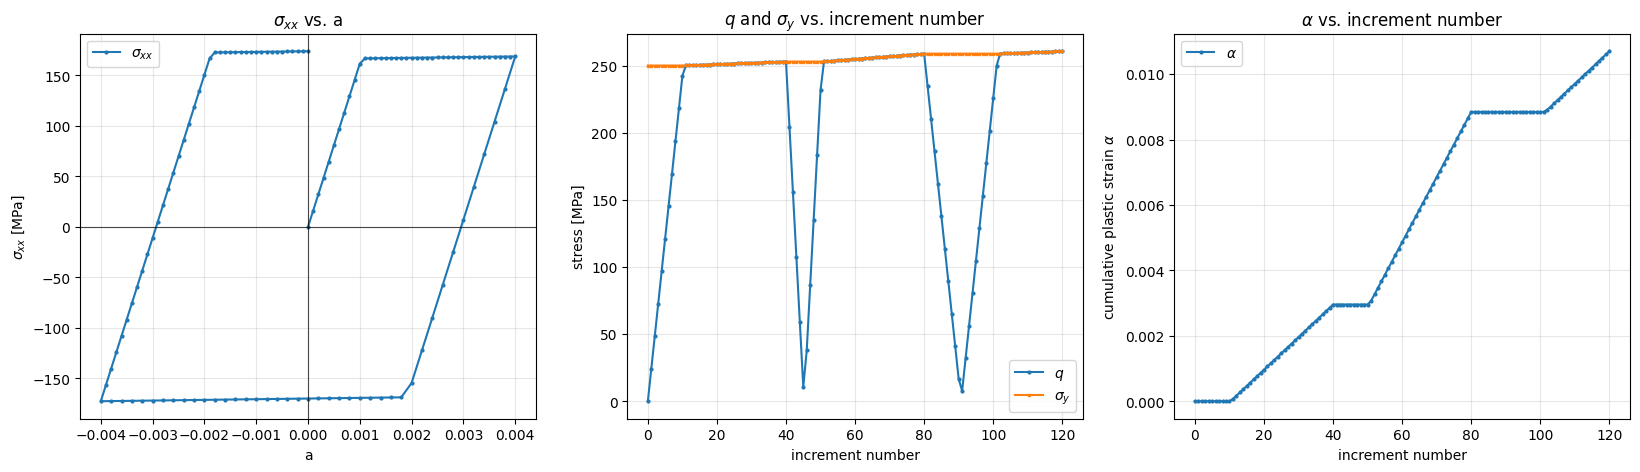

In [12]:
# TODO: 履歴ドライバ、3図、各ステップの検証をここに実装
# 初期状態も保存する。ゼロ状態の配列は .copy() して状態を分離する。
# 未実装時に成功表示をしない。
def history_driver(a, stress0, ep0, alpha0, nd):
    """等方ひずみ経路に沿った材料点履歴を時間積分する。

    各区間を `nd` 分割し、全ひずみパラメータ `a` の変化に応じて
    `j2_update` を呼び出して応力・塑性ひずみ・累積塑性ひずみの履歴を生成する。

    Parameters
    ----------
    a : array-like, shape (nb + 1,)
        各境界点での一軸ひずみパラメータの配列。
        例: [0.0, 0.004, -0.004, 0.0] のような経路を表す。
    stress0 : array-like, shape (3, 3)
        初期応力テンソル。対称3×3配列。
    ep0 : array-like, shape (3, 3)
        初期塑性ひずみテンソル。対称3×3配列。
    alpha0 : float
        初期累積塑性ひずみ量。
    nd : int
        1区間あたりの増分数。各区間を `nd` 回に分割して更新する。

    Returns
    -------
    stress : numpy.ndarray, shape (n, 3, 3)
        各ステップでの応力履歴。
    ep : numpy.ndarray, shape (n, 3, 3)
        各ステップでの塑性ひずみ履歴。
    alpha : numpy.ndarray, shape (n,)
        各ステップでの累積塑性ひずみ履歴。
    da : numpy.ndarray, shape (n - 1,)
        各ステップでの累積塑性ひずみ増分履歴。
        弾性ステップでは 0.0 を返す。
    """
    nb = a.shape[0]-1
    n = nd*nb+1
    stress, ep = np.zeros((2, n, 3, 3))
    alpha = np.zeros(n)
    da = np.zeros(n-1)
    stress[0], ep[0], alpha[0] = stress0.copy(), ep0.copy(), alpha0
    for ib in range(nb):
        deps = np.diag([1., -0.5, -0.5])*(a[ib+1]-a[ib])/nd
        step = nd*ib
        for _ in range(nd):
            stress[step+1], ep[step+1], alpha[step+1], da[step] = j2_update(deps, stress[step], ep[step], alpha[step], E, nu, sigma_y0, H)
            step += 1
    return stress, ep, alpha, da

def check_ex4():
    a = np.array([0., 0.004, -0.004, 0.])
    nb = a.shape[0]-1
    nd = 40
    stress, ep, alpha, da = history_driver(a, Z, Z, 0., nd)
    assert np.all(da >= 0), "全ステップで累積塑性ひずみは非減少でなければならない"
    q = np.array([invariants(s)[3] for s in stress])
    f = q-sigma_y0-H*alpha
    assert np.all(f <= 1e-7), "降伏関数fは許容値(1e-7 MPa)以下でなければならない"
    assert np.all(np.abs(f[np.concatenate([[0], da]) > 0]) <= 1e-7), "塑性ステップで降伏関数の絶対値|f|は許容値(1e-7 MPa)以下でなければならない"
    eps = np.zeros_like(stress)
    for ib in range(nb):
        deps = np.diag([1., -0.5, -0.5])*(a[ib+1]-a[ib])/nd
        for i in range(nd):
            eps[nd*ib+i+1] = eps[nd*ib]+deps*(i+1)
    assert np.allclose(np.array([elastic_stress(epsi-epi, E, nu) for epsi, epi in zip(eps, ep)]), stress, atol=1e-7)
    posda_negep = np.arange(nb*nd)[(da > 0)*(np.diff(ep[:, 0, 0]) < 0)]
    print("弾性除荷中の累積塑性ひずみ: ", alpha[nd+1])
    for i in range(nd*(nb-1)):
        if da[nd+1+i] > 0:
            print("反転塑性中の塑性ひずみ[MPa](xx成分, 10ステップ): ", ep[nd+1+i:nd+1+i+10, 0, 0])
            break
    print(f"終点(全ひずみゼロ)での応力[MPa]: ", stress[-1])
    print(f"塑性ひずみ減少かつ累積塑性ひずみ増加区間: [{posda_negep[0]}, {posda_negep[-1]+1}]")

checkpoint("演習4の体積一定ひずみ", check_ex4)

a = np.array([0., 0.004, -0.004, 0.])
stress, ep, alpha, da = history_driver(a, Z, Z, 0., 40)
q = np.array([invariants(s)[3] for s in stress])
sigma_y = sigma_y0+H*alpha
step = np.arange(q.shape[0])
a_hist = np.empty(stress.shape[0], dtype=float)
a_hist[0] = a[0]
idx = 1
for ib in range(a.shape[0]-1):
    seg = np.linspace(a[ib], a[ib+1], 41)[1:]
    nseg = seg.size
    a_hist[idx:idx+nseg] = seg
    idx += nseg
a0 = np.array([0., 0.])
stress0, ep0, alpha0, da0 = history_driver(a0, Z, Z, 0., 40)
print("端点情報のみで計算した最終状態での応力、塑性ひずみ、累積相当塑性ひずみ", stress0[-1], ep0[-1], alpha0[-1])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ax0 = axes[0]
ax0.plot(a_hist, stress[:, 0, 0], marker='o', markersize=2, linewidth=1.5, label=r'$\sigma_{xx}$')
ax0.axhline(0.0, color='black', linewidth=0.8, alpha=0.7)
ax0.axvline(0.0, color='black', linewidth=0.8, alpha=0.7)
ax0.set_xlabel('a')
ax0.set_ylabel(r'$\sigma_{xx}$ [MPa]')
ax0.set_title(r'$\sigma_{xx}$ vs. a')
ax0.grid(True, alpha=0.3)
ax0.legend()
ax1 = axes[1]
ax1.plot(step, q, marker='o', markersize=2, linewidth=1.5, label=r'$q$')
ax1.plot(step, sigma_y, marker='s', markersize=2, linewidth=1.5, label=r'$\sigma_y$')
ax1.set_xlabel('increment number')
ax1.set_ylabel('stress [MPa]')
ax1.set_title(r'$q$ and $\sigma_y$ vs. increment number')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax2 = axes[2]
ax2.plot(step, alpha, marker='o', markersize=2, linewidth=1.5, label=r'$\alpha$')
ax2.set_xlabel('increment number')
ax2.set_ylabel(r'cumulative plastic strain $\alpha$')
ax2.set_title(r'$\alpha$ vs. increment number')
ax2.grid(True, alpha=0.3)
ax2.legend()
# plt.tight_layout()
plt.show()

## 演習5 — 数値更新を信頼するための検証（15点）

本文5.3・7節。検証対象を以下の四つに分ける。

1. **座標回転**（4点）：$z$ 軸回り37度の直交行列 $\mathbf Q$ を自作し、$\mathbf Q^T\mathbf Q=\mathbf I$ を確認する。ゼロから塑性負荷した状態を作り、そこからせん断を加える更新を使う。全入力テンソルを $\mathbf Q^T\mathbf A\mathbf Q$ へ変換して更新し、出力応力と塑性ひずみが同じ規則で変換され、$\alpha$ が不変なことを検証する。応力誤差のFrobeniusノルムを表示する。
2. **入力履歴の保存**（3点）：塑性履歴が非ゼロの状態から同じ増分を2回独立に呼び出す。入力配列の呼出し前後の完全一致と二つの出力の一致を確認する。連続する二増分として呼ぶ実験とは区別する。
3. **非比例経路の細分化**（5点）：まず全ひずみをゼロから $\operatorname{diag}(0.004,-0.002,-0.002)$ へ、続いて対角成分を保持したまま $\gamma_{xy}=0.008$（行列成分0.004）まで増加させる。各直線区間を $N=10,20,40,80$ 分割する。$N=640$ の比較用細分解に対して、最終応力差ノルム（MPa）と最終 $\alpha$ の絶対差を表にする。
4. **解釈**（3点）：局所の降伏残差と負荷経路の離散化誤差が違う理由を説明する。$N=80$ の応力差が $N=10$ より小さくなることを確認する。細分解を厳密解と呼ばず、特定の収束次数は合格条件にしない。材料点のみなのでメッシュ収束と呼ばない。

1〜3は実装・数値検証10点、理由と結果の説明を計5点として評価する。比例単調経路だけで刻み依存がないと結論しない。

### 記述・数式の答案

- 導出・予測：
  - 後退Euler法により流れ則を増分端で評価すると、途中の流動方向変化を考慮できない。降伏残差を限りなくゼロに近づけてもこの影響は残る。

- 計算結果と検証の解釈：
  - ステップ細分化検証
  
  |分割数|最終応力差ノルム [MPa]|最終累積塑性ひずみの絶対差|
  |---|---|---|
  |10|4.398677615812163|5.318338194682144e-05|
  |20|2.111420209141613|2.9486758534271428e-05|
  |40|1.0038005477260674|1.5242095394942326e-05|
  |80|0.46358982110844654|7.3635105986933486e-06|

  - 分割数におよそ反比例して$N=640$での細分解との応力差および累積塑性ひずみの差(の絶対値)は小さくなり、$N=80$の応力差は$N=10$より小さくなる。

In [6]:
# TODO: 回転比較、入力不変性、細分化の表を実装
# 応力のノルム: np.linalg.norm(stress_coarse - stress_fine)
# 内部状態を初期化してから各 N の経路を計算する。
def history_driver_general(eps_sta, eps_end, stress0, ep0, alpha0, n):
    """総ひずみ経路を等分割し、材料点の履歴を積分する。

    Parameters
    ----------
    eps_sta : array-like, shape (3, 3)
        経路開始点の全ひずみテンソル。対称3x3の微小ひずみテンソル。
    eps_end : array-like, shape (3, 3)
        経路終点の全ひずみテンソル。対称3x3の微小ひずみテンソル。
    stress0 : array-like, shape (3, 3)
        初期応力テンソル。対称3x3配列。
    ep0 : array-like, shape (3, 3)
        初期塑性ひずみテンソル。対称3x3配列。
    alpha0 : float
        初期累積塑性ひずみ量。
    n : int
        区間を分割するステップ数。各ステップの増分は
        ``(eps_end - eps_sta) / n`` で与える。

    Returns
    -------
    stress : numpy.ndarray, shape (n + 1, 3, 3)
        各ステップの応力履歴。先頭は初期応力。
    ep : numpy.ndarray, shape (n + 1, 3, 3)
        各ステップの塑性ひずみ履歴。先頭は初期塑性ひずみ。
    alpha : numpy.ndarray, shape (n + 1,)
        各ステップの累積塑性ひずみ履歴。先頭は初期値。
    da : numpy.ndarray, shape (n,)
        各ステップでの累積塑性ひずみ増分履歴。弾性ステップでは 0.0。
    """
    stress, ep = np.zeros((2, n+1, 3, 3))
    alpha = np.zeros(n+1)
    da = np.zeros(n)
    stress[0], ep[0], alpha[0] = stress0.copy(), ep0.copy(), alpha0
    deps = (eps_end-eps_sta)/n
    for i in range(n):
        stress[i+1], ep[i+1], alpha[i+1], da[i] = j2_update(deps, stress[i], ep[i], alpha[i], E, nu, sigma_y0, H)
    return stress, ep, alpha, da

rot_deg = 37
rot_rad = rot_deg*np.pi/180
q_mat = np.array([
    [np.cos(rot_rad), -np.sin(rot_rad), 0],
    [np.sin(rot_rad),  np.cos(rot_rad), 0],
    [0, 0, 1]])
np.testing.assert_allclose(q_mat.T@q_mat, I, atol=1e-7)

deps0 = np.diag([0.003, 0., 0.])
stress, ep, alpha, da = j2_update(deps0, Z, Z, 0., E, nu, sigma_y0, H)
deps1 = np.zeros_like(deps)
deps1[0, 1], deps1[1, 0] = 0.001, 0.001
stress0, ep0, alpha0, da0 = j2_update(deps1, stress, ep, alpha, E, nu, sigma_y0, H)
stress_rot, ep_rot, alpha_rot, da = j2_update(q_mat.T@deps1@q_mat, q_mat.T@stress@q_mat, q_mat.T@ep@q_mat, alpha, E, nu, sigma_y0, H)
np.testing.assert_allclose(q_mat.T@stress0@q_mat, stress_rot, atol=1e-7)
np.testing.assert_allclose(q_mat.T@ep0@q_mat, ep_rot, atol=1e-7)
np.testing.assert_allclose(alpha0, alpha_rot, atol=1e-7)
print("応力誤差のFrobeniusノルム [MPa]: ", np.linalg.norm(q_mat.T@stress0@q_mat-stress_rot))

deps = np.diag([0.003, 0., 0.])
sigma_n = np.zeros_like(deps)
ep_n = np.zeros_like(deps)
deps_cp = deps.copy()
sigma_cp = sigma_n.copy()
ep_cp = ep_n.copy()
stress0, ep0, alpha0, da0 = j2_update(deps, sigma_n, ep_n, 0.001, E, nu, sigma_y0, H)
stress1, ep1, alpha1, da1 = j2_update(deps, sigma_n, ep_n, 0.001, E, nu, sigma_y0, H)
assert np.array_equal(deps, deps_cp), "全ひずみ増分の入力が変更されている"
assert np.array_equal(sigma_n, sigma_cp), "応力の入力が変更されている"
assert np.array_equal(ep_n, ep_cp), "塑性ひずみの入力が変更されている"
np.testing.assert_allclose(stress0, stress1, atol=1e-7)
np.testing.assert_allclose(ep0, ep1, atol=1e-7)
np.testing.assert_allclose(alpha0, alpha1, atol=1e-7)
np.testing.assert_allclose(da0, da1, atol=1e-7)

eps_mid = np.diag([0.004, -0.002, -0.002])
eps_end = eps_mid.copy()
eps_end[0, 1], eps_end[1, 0] = 0.004, 0.004
stress, ep, alpha, da = history_driver_general(Z, eps_mid, Z, Z, 0., 640)
stress, ep, alpha, da = history_driver_general(eps_mid, eps_end, stress[-1], ep[-1], alpha[-1], 640)
stress_std, alpha_std = stress[-1], alpha[-1]
print("区間分割数, 最終応力差ノルム [MPa], 最終累積塑性ひずみの絶対差")
for i in range(4):
    n = 2**i*10
    stress, ep, alpha, da = history_driver_general(Z, eps_mid, Z, Z, 0., n)
    stress, ep, alpha, da = history_driver_general(eps_mid, eps_end, stress[-1], ep[-1], alpha[-1], n)
    print(n, np.linalg.norm(stress[-1]-stress_std), abs(alpha[-1]-alpha_std))

応力誤差のFrobeniusノルム [MPa]:  2.5618982671915014e-14
区間分割数, 最終応力差ノルム [MPa], 最終累積塑性ひずみの絶対差
10 4.398677615812163 5.318338194682144e-05
20 2.111420209141613 2.9486758534271428e-05
40 1.0038005477260674 1.5242095394942326e-05
80 0.46358982110844654 7.3635105986933486e-06


## 演習6 — 積分点からCAEレビューへ（10点）

本文6・8節。以下は教材用の架空データであり、実務データは不要。

| ケース | 同一積分点・同一時刻の出力 | 補足 |
| --- | --- | --- |
| A | $q=180$ MPa、$\alpha=0.02$、$\Delta\alpha=0$ | 共通定数、除荷中 |
| B | $q=270$ MPa、$\alpha=0.02$、$\Delta\alpha>0$ | 共通定数 |
| C | $q=290$ MPa、$\alpha=0.02$ | 共通定数の速度非依存・等方硬化モデルと申告 |

1. A〜Cで現在の降伏応力と $f$ を計算し、モデルと整合するかを説明する。Cの原因は断定せず、最初に照合する情報を二つ挙げる（3点）。
2. ある反復プログラムはNewton反復ごとに `alpha_n = alpha_new` とし、確定済み履歴を書き換えている。何が二重計上されるかを説明し、確定・試行状態を分けた擬似コードを書く。材料点の $f=0$ だけで全体釣合いを保証できない理由も述べる（3点）。
3. $\sigma_{zz}=0$ に上書きした3D更新を平面応力モデルとして採用できるか。平面ひずみとの違いを含め説明する。小ひずみのコードを大回転へそのまま使えない理由を、物質座標・Cauchy応力の面積基準と結び付ける（2点）。
4. LS-DYNA等の相当塑性ひずみをこの $\alpha$ と比較する前に、材料則・出力位置・履歴の三観点で確認項目を挙げる。節点平均表示だけでの検証が不足する理由も書く（2点）。

採点は材料モデル内の整合性と、データから言える限界の区別を重視する。

### 記述・数式の答案

- 導出・予測：
  - A, B, Cの降伏応力$\sigma_{y0}+H\alpha$はすべて270MPa。$f$はそれぞれ-90, 0, 20MPa。Aは$f\lt0$であるから$\Delta\alpha=0$かつ除荷中、Bは$f=0$であるから$\Delta\alpha\gt0$と整合。Cは$f\gt0$で本モデルで許容されないため、同じ層での比較であるか、平滑化の処理の違いを確認する。
  - 累積塑性ひずみ増分が二重計上されるため、下記のように確定・試行状態を分ける。
  ```
  ステップnの全ひずみ、応力、塑性ひずみ、累積塑性ひずみを内部変数にコピー
    → 節点変位を仮定
    → 各積分点の全ひずみ増分を計算
    → コピーした内部変数から材料更新し、試行応力と試行内部変数を計算
    → 内力と自由残差を計算し、要すれば変位を修正して反復
    → 収束した場合、試行応力と試行内部変数をステップn+1での値とする
  ```
  - 自由残差は応力の積分から得られた内力と外力の差であり、$f=0$だけでは静解析の力の釣合いを保証できない。また、力の釣合いに関する残差を収束させても負荷経路の離散化誤差がキャンセルされるわけではないため、応力の収束は保証されない。
  - 更新した面外応力をゼロで上書きすると計算済みのひずみと構成則が整合しなくなるため、面外応力がゼロとなるようなひずみを算出する平面応力モデルと整合するとは限らない。平面ひずみでは面外全ひずみをゼロとする応力を計算する。
  - 材料点は物質座標(基準配置での座標)で定義されており、Cauchy応力は現在面積基準で定義される量であるため、大回転へそのまま適用すると剛体回転を変形として扱ってしまう問題や、応力の方向変化を正確に捉えられない問題が発生する
  - 速度非依存の等方硬化であるか、平滑化のアルゴリズム、初期ひずみの有無、積分点・時刻・層の同一性、塑性履歴と累積量の定義を確認する
  - 平均応力テンソルから算出される$q$と各節点での$q$の平均は一般に異なる

## 提出前チェックとフィードバック

- [ ] 6問の記述・数式・自作コード・出力を保存した。
- [ ] 再起動後の全セル実行で例外・「未実装」がない。
- [ ] 弾性・塑性・反転・静水圧・純せん断・H=0を別々に確認した。
- [ ] 応力更新の入力保存、回転、負荷経路細分化を数値で確認した。
- [ ] 学習ログに、分かったこと、つまずいた導出、検証結果、改善案を記入した。

### 学習者コメント

- 流れ則から累積量・材料更新へのつながり：
- 実装を自分で設計する余地と検証条件の具体性：
- 次回確認したいこと：